In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Datei laden (nur einmal nötig!)
df = pd.read_csv('appleAppData.csv', nrows=1000) 

# Die Spalten anzeigen
df.columns.tolist()

['App_Id',
 'App_Name',
 'AppStore_Url',
 'Primary_Genre',
 'Content_Rating',
 'Size_Bytes',
 'Required_IOS_Version',
 'Released',
 'Updated',
 'Version',
 'Price',
 'Currency',
 'Free',
 'DeveloperId',
 'Developer',
 'Developer_Url',
 'Developer_Website',
 'Average_User_Rating',
 'Reviews',
 'Current_Version_Score',
 'Current_Version_Reviews']

In [20]:
import pandas as pd

# Wir nutzen den exakten Namen deiner Datei
file_name = 'appleAppData.csv'

# Nur die Spalten laden, die für die erste Analyse wichtig sind
cols_to_use = ['App_Name', 'Developer', 'Average_User_Rating', 'Reviews', 'Updated', 'Price', 'Primary_Genre']

# Den kompletten Datensatz laden
df_full = pd.read_csv(file_name, usecols=cols_to_use)

# Erweiterte Suche nach Behörden und offiziellen Stellen
# Wir nehmen deutsche und englische Begriffe, um alles zu erwischen
keywords = ['Stadt', 'Bundes', 'Landes', 'Gov', 'Official', 'Authority', 'Ministry', 'Police', 'Department', 'Amt']
filter_condition = df_full['Developer'].str.contains('|'.join(keywords), case=False, na=False)

behoerden_apps = df_full[filter_condition].copy()

print(f"Anzahl gefundener Apps: {len(behoerden_apps)}")
print("-" * 30)
# Zeig uns eine bunte Mischung aus den Ergebnissen
#if not behoerden_apps.empty:
#    print(behoerden_apps[['App_Name', 'Developer', 'Average_User_Rating']].sample(min(10, len(behoerden_apps))))

Anzahl gefundener Apps: 4249
------------------------------


In [21]:
# Gezielte Suche nach deutschen Behörden
de_keywords = ['Stadt', 'Gemeinde', 'Landkreis', 'Bundes', 'Ministerium', 'Polizei', 'Amt', 'Behörde']

# Wir filtern den gesamten Datensatz nochmal nur nach diesen deutschen Begriffen
de_behoerden = df_full[df_full['Developer'].str.contains('|'.join(de_keywords), case=False, na=False)].copy()

print(f"Anzahl deutscher Behörden-Treffer: {len(de_behoerden)}")
#if not de_behoerden.empty:
#    print(de_behoerden[['App_Name', 'Developer', 'Average_User_Rating']].head(20))

Anzahl deutscher Behörden-Treffer: 1096


In [11]:
# Wir definieren Kategorien, die wir GAR NICHT wollen
garbage_genres = ['Games', 'Social Networking', 'Entertainment', 'Music', 'Lifestyle']

# Filter: 
# 1. Muss in unseren de_keywords sein
# 2. Darf NICHT in den garbage_genres sein
clean_behoerden = de_behoerden[~de_behoerden['Primary_Genre'].isin(garbage_genres)].copy()

# Jetzt schauen wir uns die Top-Entwickler der ÜBRIG GEBLIEBENEN an
print(f"Echte Treffer nach Reinigung: {len(clean_behoerden)}")
print(clean_behoerden['Developer'].value_counts().head(20))

Echte Treffer nach Reinigung: 762
Developer
Deutsche Stadtmarketing GmbH                   28
AirBeamTV BV                                   17
Merck KGaA (Darmstadt, Germany)                16
Mohamed Rahamtalla                             15
John goodstadt                                  8
Bundeskunsthalle                                7
Ley Kamthong                                    6
Rayen Kamta                                     6
DreamTeam Apps                                  6
Amtology                                        6
Bundesagentur für Arbeit                        5
Katholische Gesamtkirchengemeinde Nuernberg     5
Landkreis Osnabrück                             5
Bundesamt für Gesundheit BAG                    5
Samtech S.A.                                    5
Wamtek GmbH                                     5
Mohamad Gharamti                                5
AAAMT, Inc                                      4
KoamTac. Inc                                    4
Grosss

In [22]:
#print("Top Kategorien der gereinigten Liste:")
#print(clean_behoerden['Primary_Genre'].value_counts())

In [16]:
# Wir schauen uns gezielt die größte Gruppe an: Travel
travel_apps = clean_behoerden[clean_behoerden['Primary_Genre'] == 'Travel']

print("Stichprobe der Travel-Apps (Behörden-Kontext):")
print(travel_apps[['App_Name', 'Developer']].sample(min(15, len(travel_apps))))

Stichprobe der Travel-Apps (Behörden-Kontext):
                             App_Name  \
1181125           Parken in Straubing   
935313                   Aalen GeoApp   
1161117             Gemeinde Bolligen   
1177525                    Großerlach   
839956                      Neubulach   
787095               Gemeinde Roßbach   
968485                RiderTaxi Rider   
165042   Wissenschaftsstadt Darmstadt   
1189523               Auslandsservice   
1210243                Sutz-Lattrigen   
1170524                       DORFnet   
1213032             Mühlenbecker Land   
926464                          COONO   
1203625                Stadt Gaggenau   
1161124              Gemeinde Nußloch   

                                                 Developer  
1181125                                    Stadt Straubing  
935313                                         Stadt Aalen  
1161117                         Einwohnergemeinde Bolligen  
1177525                                Gemeinde Groß

In [17]:
# 1. Wie viele Apps sind "Geister-Apps" (0 Bewertungen)?
zero_ratings = (clean_behoerden['Average_User_Rating'] == 0).sum()
percent_zero = (zero_ratings / len(clean_behoerden)) * 100

# 2. Was ist das Durchschnitts-Rating der Apps, die ÜBERHAUPT bewertet wurden?
rated_apps = clean_behoerden[clean_behoerden['Average_User_Rating'] > 0]
avg_rating = rated_apps['Average_User_Rating'].mean()

print(f"Analyse der {len(clean_behoerden)} Behörden-Apps:")
print(f"-> {zero_ratings} Apps ({percent_zero:.1f}%) haben 0 Bewertungen.")
print(f"-> Das Durchschnitts-Rating der bewerteten Apps liegt bei: {avg_rating:.2f} Sternen.")

Analyse der 762 Behörden-Apps:
-> 624 Apps (81.9%) haben 0 Bewertungen.
-> Das Durchschnitts-Rating der bewerteten Apps liegt bei: 4.00 Sternen.


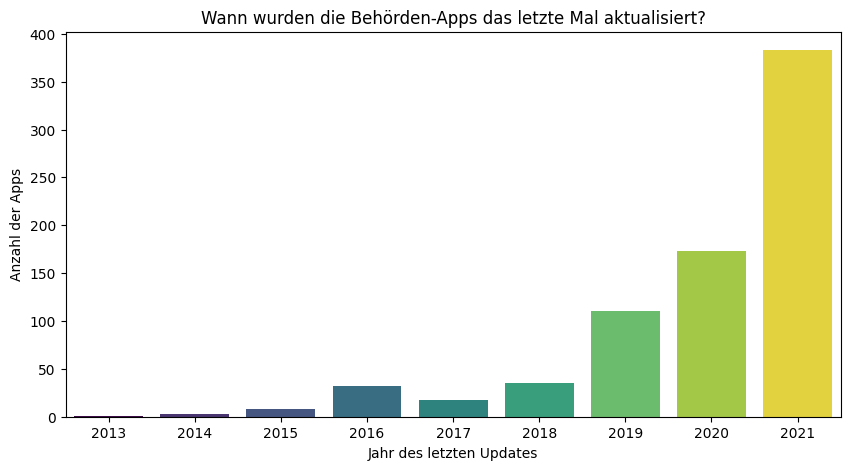

In [23]:
# 1. Datum umwandeln
clean_behoerden['Updated'] = pd.to_datetime(clean_behoerden['Updated'])

# 2. Das Jahr extrahieren
clean_behoerden['Update_Year'] = clean_behoerden['Updated'].dt.year

# 3. Grafik: Wann war das letzte Update?
plt.figure(figsize=(10, 5))
sns.countplot(x='Update_Year', data=clean_behoerden, hue='Update_Year', palette='viridis', legend=False)

plt.title('Wann wurden die Behörden-Apps das letzte Mal aktualisiert?')
plt.xlabel('Jahr des letzten Updates')
plt.ylabel('Anzahl der Apps')
plt.show()

C:\Users\Trainee\AppData\Local\Temp\ipykernel_7060\2856587983.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x='Average_User_Rating', y='Primary_Genre', data=rated_only,


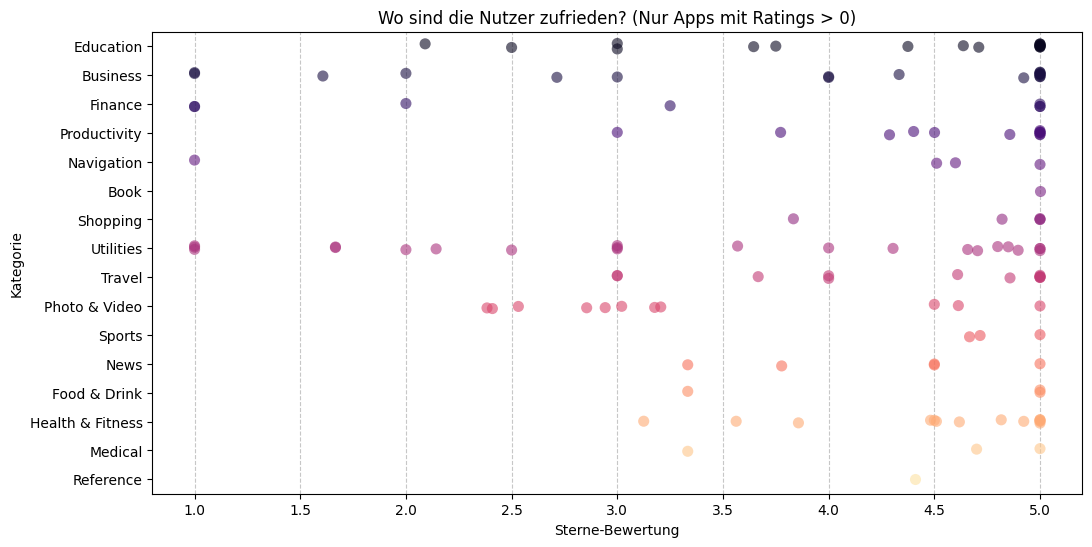

In [ ]:
import seaborn as sns

# Wir filtern nur die Apps, die überhaupt Bewertungen haben
rated_only = clean_behoerden[clean_behoerden['Average_User_Rating'] > 0]

plt.figure(figsize=(12, 6))
sns.stripplot(x='Average_User_Rating', y='Primary_Genre', data=rated_only, 
              jitter=True, size=8, alpha=0.6, palette='magma')

plt.title('Wo sind die Nutzer zufrieden? (Nur Apps mit Ratings > 0)')
plt.xlabel('Sterne-Bewertung')
plt.ylabel('Kategorie')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [24]:
clean_behoerden.to_csv('meine_gefilterten_apps.csv', index=False)